In [1]:
%pip install matplotlib numpy scikit-learn pandas --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Package imports
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import numpy as np

# Task 1 Implement Logistic Regression

- Neural Network Logistic regression
- Handle different number of input features
- Handle different input training samples

In [5]:
# Prediction function
def predict(Xi, W, b):
    z = np.dot(Xi, W) + b
    y_hat = 1 / (1 + np.exp(-z))
    return y_hat

In [49]:
# Stochastic Gradient Descent function
def stochastic_gradient_descent(X, y, W, b, alpha=0.01, max_iters=1000, threshold=1e-4):
    # TODO: Stop with the average cost function change less than threshold
    # This version does not have loops on backpropagation because it is for just one neuron
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0

    while not stopping:
        # Randomly select one data point #Sample size = 1        
        i_random = np.random.randint(0, high=N)
        y_hat = predict(X[i_random], W, b)
        J_current = -(y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))[0]
        error = y_hat - y[i_random]
        
        delta_W = error * X[i_random]
        delta_b = error
        
        W -= alpha * delta_W
        b -= alpha * delta_b

        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0:
            if iteration % (5*N) == 0:
                # print("Average cost function over epoch:", J_running / N)
                print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                print("Difference in cost function:", abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
        
    return W, b

# Task 2 Implement Logistic Regression

- Read both files
- Split train(70), test(15), validation(15)
- Train logistic regressor and check performance
- Scatter plot of results

In [7]:
# Reading data function
def read_data(file_path):
    df = pd.read_csv(file_path)
    y = df['Class'].values   # Labels
    X = df.drop('Class', axis=1).values  # Features
    return X, y

In [8]:
def split_data(X, y, train_ratio=0.7, test_ratio=0.15, validation_ratio=0.15, random_state=1):
    # https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    X_train, X_test_pre, y_train, y_test_pre = sklearn.model_selection.train_test_split(
    X, y, train_size=train_ratio, random_state=random_state)
    
    X_test, X_val, y_test, y_val = sklearn.model_selection.train_test_split(
    X_test_pre, y_test_pre, train_size=test_ratio/(test_ratio + validation_ratio), random_state=random_state)
    
    return X_train, y_train, X_test, y_test, X_val, y_val

## Blobs 600 dataset

In [46]:
file_path = 'Datasets/blobs600.csv'
# file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X_train, y_train, W, b, alpha=0.01, max_iters=10000, threshold=1e-4)
# print("Trained Weights:", W_trained)
# print("Trained Bias:", b_trained)

Epoch: 5  Cost: 14.491326444785939  Previous Cost: 18.79767240378971
Difference in cost function: 4.306345959003773
Epoch: 10  Cost: 13.193024733232743  Previous Cost: 11.004499368168382
Difference in cost function: 2.1885253650643612
Epoch: 15  Cost: 8.436403518387252  Previous Cost: 6.729370814863911
Difference in cost function: 1.7070327035233408
Epoch: 20  Cost: 4.746706464540707  Previous Cost: 5.879954139497462
Difference in cost function: 1.1332476749567553


In [37]:
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)

Train Accuracy: 0.9976190476190476
Test Accuracy: 0.9888888888888889
Validation Accuracy: 0.9888888888888889


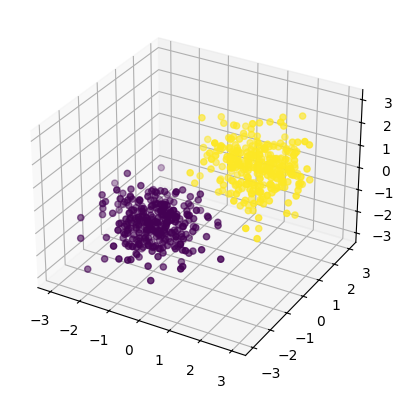

In [38]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_all[:, 0], X_all[:, 1], X_all[:, 2], c=y_pred_all)

## Circles 500 dataset

In [50]:
# file_path = 'Datasets/blobs600.csv'
file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X_train, y, W, b, alpha=1e-4, max_iters=10000, threshold=1e-6)
print("Trained Weights:", W_trained)
print("Trained Bias:", b_trained)

Epoch: 5  Cost: 242.76672585946253  Previous Cost: 242.75791476197057
Difference in cost function: 0.008811097491957298
Epoch: 10  Cost: 242.73321485531008  Previous Cost: 242.72339249002098
Difference in cost function: 0.009822365289096524
Epoch: 15  Cost: 242.6667995644584  Previous Cost: 242.74261753176293
Difference in cost function: 0.07581796730454471
Epoch: 20  Cost: 242.5943837559509  Previous Cost: 242.57949554065328
Difference in cost function: 0.01488821529761708
Epoch: 25  Cost: 242.53320082554768  Previous Cost: 242.5657899279666
Difference in cost function: 0.03258910241891044
Trained Weights: [0.01119526 0.00745474]
Trained Bias: [0.00265608]


In [753]:
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)

Train Accuracy: 0.5257142857142857
Test Accuracy: 0.64
Validation Accuracy: 0.5066666666666667


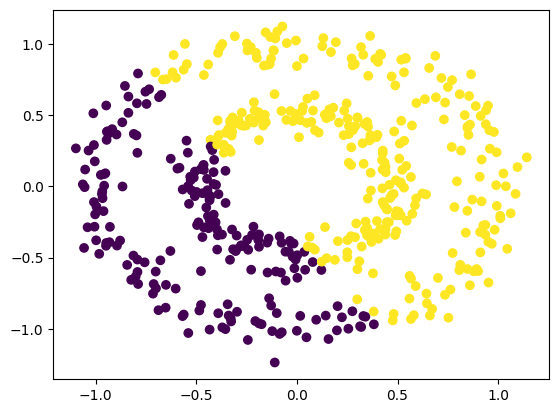

In [754]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X_all[:, 0], X_all[:, 1], c=y_pred_all)

# Task 3: Implement and Test a Shallow Neural Network

- 1 hidden layer
- 1 output node
- Support different number of inputs
- Support different number of nodes in the hidden layer

Test
- Test previous datasets with different number of nodes in the hidden layer
- Measure performance

In [51]:
def parameter_initialization(X, neurons_hidden_layer):
    np.random.seed(3301)
    W1 = np.random.normal(0,0.01,size=(neurons_hidden_layer,X.shape[1]))
    W2 = np.random.normal(0,0.01,size=(1,neurons_hidden_layer))
    W = [W1, W2]

    b1 = np.random.normal(0,0.01,size=(neurons_hidden_layer))
    b2 = np.random.normal(0,0.01,size=(1))
    b = [b1, b2]
    
    # https://numpy.org/devdocs/reference/generated/numpy.zeros.html
    z1 = np.zeros(shape=(neurons_hidden_layer))
    z2 = np.zeros(shape=(1))
    z = [z1, z2]
    a0 = np.zeros(shape=(X.shape[1]))
    a1 = np.zeros(shape=(neurons_hidden_layer))
    a2 = np.zeros(shape=(1))
    a = [a0, a1, a2]

    return W, b, z, a

In [52]:
# Forward propagation function
def forward_propagation(Xi, W, b, z, a):
   # X[observation][feature] 
   # W[layer][destination_node][source_node]
   # b[layer][destination_node]
   # z[layer][destination_node]
   # a[layer][destination_node]
   a[0] = Xi # Inputs are activations of layer 0
   for layer in range(1, 3):
      for destination_node in range(1, len(z[layer-1])+1):
         # Linear transformation 
         z[layer-1][destination_node-1] = np.dot(a[layer-1], W[layer-1][destination_node-1]) + b[layer-1][destination_node-1]
         # Activation function (Using logistic function)
         a[layer][destination_node-1] = 1 / (1 + np.exp(-z[layer-1][destination_node-1]))

   y_hat = a[layer][destination_node-1] # Output of the last layer is the prediction
   return y_hat, a, z

In [53]:
# Return only the prediction
def predict(X, W, b, z, a):
    y_hats = np.zeros(shape=(X.shape[0]))
    for i, Xi in enumerate(X):
        y_hat, a, z = forward_propagation(Xi, W, b, z, a)
        y_hats[i] = y_hat
    return y_hats

In [81]:
# Backpropagation and gradient descent function
def gradient_descent_t3(X, y, W, b, a, z, alpha=0.01, max_iters=1000, threshold=1e-4, neurons_hidden_layer=5):
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0
    # Initialize delta parameters for gradient descent
    delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
    delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
    delta_W = [delta_W1, delta_W2]

    delta_b1 = np.zeros(shape=(neurons_hidden_layer))
    delta_b2 = np.zeros(shape=(1))
    delta_b = [delta_b1, delta_b2]

    delta_z1 = np.zeros(shape=(neurons_hidden_layer))
    delta_z2 = np.zeros(shape=(1))
    delta_z = [delta_z1, delta_z2]
    
    while not stopping:
        # Randomly select one data point #Sample size = 1       
        i_random = np.random.randint(0, high=N)
        y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        
        # Backpropagation step
        error = y_hat - y[i_random] 
        for layer in range(len(W), 0, -1):
            # Output layer gradients
            if layer == len(W):
                delta_z[layer-1] = error
                # https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html
                delta_W[layer-1] = error * a[layer-1].reshape(1, -1)
                delta_b[layer-1] = error
            # Hidden layer gradients
            else:
                # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
                delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * W[layer].reshape(-1)
                # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
                delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
                delta_b[layer-1] = delta_z[layer-1]

        # Update parameters step
        for layer in range(1, len(W)+1):
            W[layer-1] -= alpha * delta_W[layer-1]
            b[layer-1] -= alpha * delta_b[layer-1]
        
        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0: # 1 Epoch finished
            if iteration % (500*N) == 0:
                # print("Average cost function over epoch:", J_running / N)
                print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                print("Difference in cost function:", abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
        
    return W, b, a, z  

## Circles 500 dataset

In [86]:
# file_path = 'Datasets/blobs600.csv'
file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 4
W, b, z, a = parameter_initialization(X, neurons_hidden_layer=neurons_hidden_layer)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained, a_trained, z_trained = gradient_descent_t3(X_train, y_train, W, b, a, z, alpha=1e-2, max_iters=800000, threshold=1e-4, neurons_hidden_layer=neurons_hidden_layer)
# print("Trained Weights:", W_trained)
# print("Trained Bias:", b_trained)

Epoch: 500  Cost: 242.0887869031901  Previous Cost: 243.4886048567379
Difference in cost function: 1.399817953547796
Epoch: 1000  Cost: 240.42095578561035  Previous Cost: 242.1073133294122
Difference in cost function: 1.6863575438018472
Epoch: 1500  Cost: 243.45571815903685  Previous Cost: 240.72656669310686
Difference in cost function: 2.729151465929988
Epoch: 2000  Cost: 26.843799333622464  Previous Cost: 24.122351083583936
Difference in cost function: 2.7214482500385273


In [87]:
treshold = 0.5
y_hat_train= predict(X_train, W_trained, b_trained, z_trained, a_trained) 
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test= predict(X_test, W_trained, b_trained, z_trained, a_trained) 
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val= predict(X_val, W_trained, b_trained, z_trained, a_trained) 
y_pred_val = (y_hat_val >= treshold).astype(int)

In [88]:
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

Train Accuracy: 0.9914285714285714
Test Accuracy: 0.9866666666666667
Validation Accuracy: 1.0


- It works with at least 3 neurons, high amount of iterations (100k or more) and learning rate of 1e-1

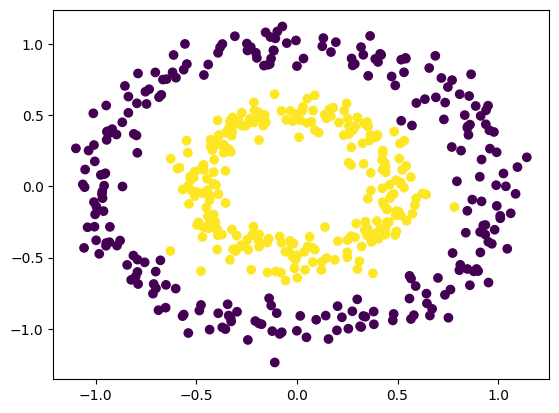

In [89]:
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X_all[:, 0], X_all[:, 1], c=y_pred_all)

In [ ]:
# neurons_hidden_layer = 5
# alpha = 0.01


# N = X.shape[0]
# stopping = False
# J_running = 0
# J_running_prev = 0
# iteration = 0
# # Initialize delta parameters for gradient descent
# delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
# delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
# delta_W = [delta_W1, delta_W2]

# delta_b1 = np.zeros(shape=(neurons_hidden_layer))
# delta_b2 = np.zeros(shape=(1))
# delta_b = [delta_b1, delta_b2]

# delta_z1 = np.zeros(shape=(neurons_hidden_layer))
# delta_z2 = np.zeros(shape=(1))
# delta_z = [delta_z1, delta_z2]


# # while not stopping:

# # Randomly select one data point #Sample size = 1       
# i_random = np.random.randint(0, high=N)
# y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
# J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))

# # Backpropagation step
# error = y_hat - y[i_random] 
# for layer in range(len(W), 0, -1):
#     print("Layer:", layer)
#     # Output layer gradients
#     if layer == len(W):
#         delta_z[layer-1] = error
#         delta_W[layer-1] = error * a[layer-1]
#         delta_b[layer-1] = error
#     # Hidden layer gradients
#     else:
#         # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
#         delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * delta_W[layer]
#         # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
#         delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
#         delta_b[layer-1] = delta_z[layer-1]

# # Update parameters step
# for layer in range(1, len(W)+1):
#     print("Layer:", layer)
#     W[layer-1] -= alpha * delta_W[layer-1]
#     b[layer-1] -= alpha * delta_b[layer-1]

# Task 4: Tackle a Challenging Task

- Read image dataset
- Filter two letters (C,F)
- Reshape images (flatten it)
- 1 hidden layer
- 1 output node
- Support different number of inputs
- Support different number of nodes in the hidden layer


Test
- Check accuracy
- Plot training curve


In [152]:
# Backpropagation and gradient descent function
def gradient_descent_t4(X, y, W, b, a, z, alpha=0.01, max_iters=1000, threshold=1e-4, neurons_hidden_layer=5):
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0
    # Initialize delta parameters for gradient descent
    delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
    delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
    delta_W = [delta_W1, delta_W2]

    delta_b1 = np.zeros(shape=(neurons_hidden_layer))
    delta_b2 = np.zeros(shape=(1))
    delta_b = [delta_b1, delta_b2]

    delta_z1 = np.zeros(shape=(neurons_hidden_layer))
    delta_z2 = np.zeros(shape=(1))
    delta_z = [delta_z1, delta_z2]
    
    J_diff_array = []
    
    while not stopping:
        # Randomly select one data point #Sample size = 1       
        i_random = np.random.randint(0, high=N)
        y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        
        # Backpropagation step
        error = y_hat - y[i_random] 
        for layer in range(len(W), 0, -1):
            # Output layer gradients
            if layer == len(W):
                delta_z[layer-1] = error
                # https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html
                delta_W[layer-1] = error * a[layer-1].reshape(1, -1)
                delta_b[layer-1] = error
            # Hidden layer gradients
            else:
                # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
                delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * W[layer].reshape(-1)
                # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
                delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
                delta_b[layer-1] = delta_z[layer-1]

        # Update parameters step
        for layer in range(1, len(W)+1):
            W[layer-1] -= alpha * delta_W[layer-1]
            b[layer-1] -= alpha * delta_b[layer-1]
        
        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0: # 1 Epoch finished
            if iteration % (100*N) == 0:
                # print("Average cost function over epoch:", J_running / N)
                print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                print("Difference in cost function:", abs(J_running - J_running_prev))
            
            J_diff_array.append(abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0   
           
    plt.plot(J_diff_array, label='Difference in Cost')
    plt.xlabel('Epochs (Every N iterations)')
    plt.ylabel('Cost')
    plt.title('Cost Function over Epochs')
    plt.legend()
    plt.show()
                             
        
    return W, b, a, z  

In [128]:
# Reading images
data = np.load("Datasets\emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

# Extract just two classes from the dataset
# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 3   # example
c2 = 6  # example

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Francisco\AppData\Local\Temp\ipykernel_42988\3310033067.py:2: SyntaxWarning: invalid escape sequence '\e'
  data = np.load("Datasets\emnist_letters_85800.npz")


In [129]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).

For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


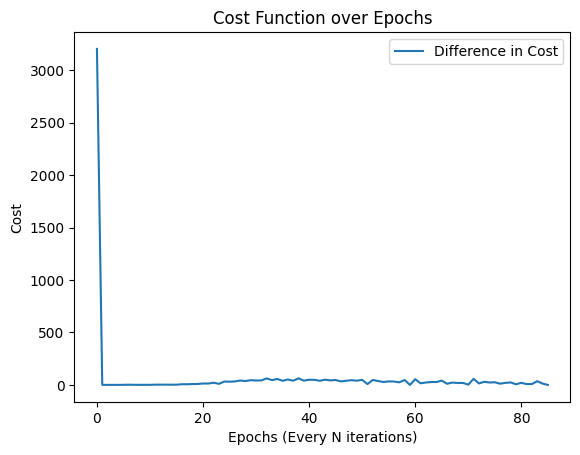

In [153]:
# Flatten the images
x_flat = x_binary.reshape(x_binary.shape[0], -1)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(x_flat, y_binary)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 1
W, b, z, a = parameter_initialization(x_flat, neurons_hidden_layer=neurons_hidden_layer)
# Training the model using Stochastic Gradient Descent
# W_trained, b_trained, a_trained, z_trained = gradient_descent_t3(X_train, y_train, W, b, a, z, alpha=1e-2, max_iters=10000, threshold=1e-4, neurons_hidden_layer=neurons_hidden_layer)
W_trained, b_trained, a_trained, z_trained = gradient_descent_t4(X=X_train, y=y_train, 
                                                                 W=W, b=b, a=a, z=z, 
                                                                 alpha=1e-4, max_iters=400000, threshold=1e-4, 
                                                                 neurons_hidden_layer=neurons_hidden_layer)


# print("Trained Weights:", W_trained)
# print("Trained Bias:", b_trained)

In [154]:
treshold = 0.5
y_hat_train= predict(X_train, W_trained, b_trained, z_trained, a_trained) 
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test= predict(X_test, W_trained, b_trained, z_trained, a_trained) 
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val= predict(X_val, W_trained, b_trained, z_trained, a_trained) 
y_pred_val = (y_hat_val >= treshold).astype(int)

In [ ]:
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)


# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

#TODO: Check why it is having good performance with just one neuron

Train Accuracy: 0.9816017316017316
Test Accuracy: 0.9797979797979798
Validation Accuracy: 0.9818181818181818


# Task 5: Deep Learning enhancements

In [905]:
# hidden_neurons_per_layer = [3,4,5,6,7,8,9,10]
# each position in the array is the hidden layer and the value is the number of neurons in that layer
def robust_parameter_initialization(X, hidden_neurons_per_layer = [3,4]):#,5,6,7,8,9,10]
    W = []
    b = []
    z = []
    a = []
    a.append(np.zeros(shape=(X.shape[1]))) # a0
    for i, num_neurons in enumerate(hidden_neurons_per_layer):
        if i == 0:
            prev_layer_neurons = X.shape[1]
        else:
            prev_layer_neurons = hidden_neurons_per_layer[i-1]
        # Create weight matrix for the current layer
        W_aux = np.random.normal(0,0.01,size=(num_neurons,prev_layer_neurons))
        W.append(W_aux)
        # Create bias vector for the current layer
        b_aux = np.random.normal(0,0.01,size=(num_neurons))
        b.append(b_aux)
        # Create z vector 
        z_aux = np.zeros(shape=(num_neurons))
        z.append(z_aux)
        # Create activation vector a
        a_aux = np.zeros(shape=(num_neurons))
        a.append(a_aux)
        # print(i, num_neurons)

    W_aux_ll = np.random.normal(0,0.01,size=(1,num_neurons))
    W.append(W_aux_ll)
    b_aux_ll = np.random.normal(0,0.01,size=(1))
    b.append(b_aux_ll)
    z_aux_ll = np.zeros(shape=(1))
    z.append(z_aux_ll)
    a_aux_ll = np.zeros(shape=(1))
    a.append(a_aux_ll)
    
    return W, b, z, a


In [904]:
np.random.seed(3301)
hidden_neurons_per_layer = [3,4,10,3]
W, b, z, a = robust_parameter_initialization(X, hidden_neurons_per_layer=hidden_neurons_per_layer)


In [902]:
W

[array([[-0.00563357, -0.02073575],
        [-0.00185757,  0.02007814],
        [-0.00349973,  0.0124223 ]]),
 array([[-0.00707935, -0.01188298, -0.00776281],
        [ 0.00468337, -0.01143027, -0.01059705],
        [ 0.0037186 , -0.01687134, -0.00743242],
        [ 0.00366145,  0.00239738,  0.00366487]]),
 array([[ 6.48546945e-03,  1.20455378e-02, -9.86031890e-03,
          3.51936307e-03],
        [ 7.33407051e-04, -1.28646044e-02, -5.00078967e-03,
         -8.72945185e-03],
        [ 4.07008071e-03, -2.88261398e-03,  1.01785694e-03,
         -3.26078342e-04],
        [-3.69845360e-03, -7.81162153e-05, -2.04540987e-03,
         -5.13655740e-03],
        [-5.29713161e-04,  7.51131338e-04,  9.93341471e-03,
         -1.88943013e-02],
        [ 6.82129220e-04,  3.74283127e-03, -2.27527408e-02,
         -2.12584379e-02],
        [-1.13900047e-02,  2.68724507e-02, -8.10419769e-03,
          4.48758826e-03],
        [ 8.06709668e-03,  1.27031426e-02,  2.59005207e-02,
         -5.31306015e-0

In [41]:
# Stochastic Gradient Descent function
def stochastic_gradient_descent_temp2(X, y, W, b, alpha=0.01, max_iters=1000, threshold=1e-4):
    # TODO: Stop with the average cost function change less than threshold
    # This version does not have loops on backpropagation because it is for just one neuron
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0
    
    J_running_array = []
    J_running_prev_array = []
    J_diff_array = []

    while not stopping:
        # Randomly select one data point #Sample size = 1        
        i_random = np.random.randint(0, high=N)
        y_hat = predict(X[i_random], W, b)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))[0]
        error = y_hat - y[i_random]
        
        delta_W = error * X[i_random]
        delta_b = error
        
        W -= alpha * delta_W
        b -= alpha * delta_b

        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0:
            if iteration % (5*N) == 0:
                # print("Average cost function over epoch:", J_running / N)
                print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                print("Difference in cost function:", abs(J_running - J_running_prev))
            J_running_prev_array.append(J_running_prev)
            J_running_array.append(J_running)
            J_diff_array.append(abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
    
    # plt.plot(J_running_array, label='Current Cost')
    plt.plot(J_diff_array, label='Difference in Cost')
    plt.xlabel('Epochs (Every N iterations)')
    plt.ylabel('Cost')
    plt.title('Cost Function over Epochs')
    plt.legend()
    plt.show()
        
    return W, b